# 02 — Bivariate copulas and tails

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/02_bivariate_copulas_and_tails.ipynb)

The building blocks, one at a time: a marginal fitted to four moments, a pair
of assets with a given copula, its exceedance-correlation curve, the
classification that reads the curve, and the family selection.

Runtime: under a minute.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

import pyvinecopulib as pv
from cvinemarketgen import (fit_johnson_su, johnson_su_moments, johnson_su_sample, fit_fleishman,
                            exceedance_curve, classify_pair, select_family, CopulaTools)

cvinemarketgen 0.2.0


## A marginal with given skewness and kurtosis: Johnson SU

The Johnson SU variable of Section 4.3 of the paper is

$$X = \mu + \sigma\, q(Z), \qquad q(z) = \xi + \lambda \sinh\!\left(\frac{z - \gamma}{\delta}\right), \qquad Z \sim N(0, 1), \quad \delta > 0, \ \lambda > 0.$$

Its four moments are closed-form functions of $(\gamma, \xi, \delta, \lambda)$;
writing $\omega = e^{1/\delta^2}$ and $\Omega = \gamma / \delta$, the mean and
variance of $q(Z)$ are
$\xi - \lambda \sqrt{\omega} \sinh\Omega$ and
$\tfrac{\lambda^2}{2}(\omega - 1)(\omega \cosh 2\Omega + 1)$,
with longer expressions for the third and fourth moments. `fit_johnson_su`
solves the moment equations for the standardized variable, mean 0 and
variance 1 with the requested skewness $\gamma_1 = -0.6$ and raw kurtosis
$\gamma_2 = 4.5$, by Nelder-Mead on the squared mismatch between the
closed-form moments and the targets, from several starting points, keeping the
solution with the smallest residual. It returns the four parameters, the
`mean` and `vol` to apply afterwards, and the residual of the fit.

In [2]:
p = fit_johnson_su(skew=-0.6, kurt=4.5, mean=0.07, vol=0.16)
p

{'gamma': 0.9526320853253712,
 'xi': 0.8936614388345187,
 'delta': 2.3203569267182225,
 'lambda': 1.9290278820199753,
 'mean': 0.07,
 'vol': 0.16,
 'residual': 3.667843019700214e-11}

`johnson_su_moments` evaluates the closed-form moments at the fitted
parameters, as $(\text{mean}, \text{variance}, \gamma_1, \gamma_2 - 3)$: they
should read $(0, 1, -0.6, 1.5)$. `johnson_su_sample` draws $n$ values by
$x = \mu + \sigma\, q(\Phi^{-1}(u))$ with $u$ uniform, $\Phi^{-1}$ the standard
normal quantile; the sample moments of 100,000 draws are compared with the
targets, the sample kurtosis being reported raw (pandas' excess kurtosis plus 3).

In [3]:
print("mean, variance, skewness, excess kurtosis of the standardized fit:", np.round(johnson_su_moments(p), 4))
x = johnson_su_sample(p, 100000, seed=1)
print("sample: mean %.4f  vol %.4f  skew %.3f  kurt %.3f" % (x.mean(), x.std(), pd.Series(x).skew(), pd.Series(x).kurtosis() + 3))

mean, variance, skewness, excess kurtosis of the standardized fit: [-0.   1.  -0.6  1.5]
sample: mean 0.0699  vol 0.1602  skew -0.631  kurt 4.700


The histogram of the draw against the normal density with the same mean and
volatility, $\phi((x - \mu)/\sigma)/\sigma$: negative skewness moves mass to
the left tail, kurtosis above 3 raises the peak and thickens both tails.

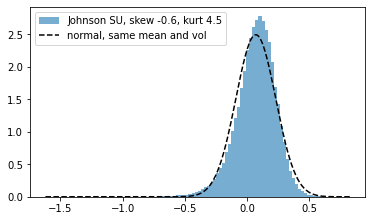

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(x, bins=100, density=True, alpha=0.6, label="Johnson SU, skew -0.6, kurt 4.5")
g = np.linspace(x.min(), x.max(), 300); ax.plot(g, np.exp(-(g - 0.07) ** 2 / (2 * 0.16 ** 2)) / (0.16 * np.sqrt(2 * np.pi)), "k--", label="normal, same mean and vol")
ax.legend(); plt.show()

## The same moments with a Fleishman cubic

Fleishman's transform (Section 3 of the paper) is the polynomial

$$Y = a + b Z + c Z^2 + d Z^3, \qquad Z \sim N(0, 1),$$

whose moments are polynomials in $(a, b, c, d)$ obtained from the normal
moments $E[Z^{2j}] = (2j-1)!!$: with $a = -c$ the mean is 0, and the variance,
skewness and kurtosis equations

$$b^2 + 6bd + 2c^2 + 15d^2 = 1, \qquad 2c\,(b^2 + 24bd + 105d^2 + 2) = \gamma_1,$$
$$24\,[bd + c^2(1 + b^2 + 28bd) + d^2(12 + 48bd + 141c^2 + 225d^2)] = \gamma_2 - 3,$$

are solved by `fsolve` from a Nelder-Mead starting point. `fit_fleishman`
returns `(a, b, c, d)`, the largest residual of the equations and a feasibility
flag. Not every pair is feasible: the cubic requires
$\gamma_2 - 3 \ge \gamma_1^2 - 2$ (a boundary below which no real solution
exists), and the second call asks for a kurtosis below it, so it returns NaN
coefficients and `feasible=False`. The draw checks the sample skewness and
kurtosis of the transformed normals.

In [5]:
f = fit_fleishman(skew=-0.6, kurt=4.5)
print(f)
z = np.random.default_rng(1).standard_normal(100000)
y = f["a"] + f["b"] * z + f["c"] * z ** 2 + f["d"] * z ** 3
print("sample: skew %.3f  kurt %.3f" % (pd.Series(y).skew(), pd.Series(y).kurtosis() + 3))
print("infeasible request:", fit_fleishman(skew=1.5, kurt=2.5))

{'a': 0.0832618673219137, 'b': 0.892367994106725, 'c': -0.0832618673219137, 'd': 0.03249348678487473, 'residual': 1.865174681370263e-14, 'feasible': True}
sample: skew -0.580  kurt 4.484
infeasible request: {'a': nan, 'b': nan, 'c': nan, 'd': nan, 'residual': nan, 'feasible': False}


## A pair with a chosen copula

By Sklar's theorem the joint distribution of a pair is
$F(x, y) = C(F_A(x), F_B(y))$: a copula $C$ on $[0, 1]^2$ and two marginals.
The cell simulates 3,000 observations of a pair whose copula is a Gumbel with
$\theta = 2$ rotated by 180 degrees. The Gumbel copula is

$$C(u, v; \theta) = \exp\!\left(-\left[(-\ln u)^\theta + (-\ln v)^\theta\right]^{1/\theta}\right), \qquad \theta \ge 1,$$

with upper-tail dependence $\lambda_U = 2 - 2^{1/\theta}$ and no lower-tail
dependence; the 180-degree rotation, $C_{180}(u, v) = u + v - 1 + C(1-u, 1-v)$,
moves the dependence to the lower tail, so $\lambda_L = 2 - 2^{1/2} = 0.59$:
joint crashes. The copula draws $(u, v)$; the marginals are Johnson SU, applied
through their quantile functions $x = q_A(\Phi^{-1}(u))$, $y = q_B(\Phi^{-1}(v))$
(standardized, mean 0 and variance 1). The scatter shows the clustering in the
lower-left corner.

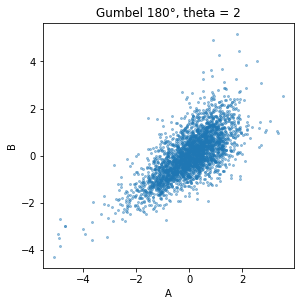

In [6]:
cop = pv.Bicop(pv.BicopFamily.gumbel, 180, np.array([[2.0]]))
u = cop.simulate(3000, seeds=[1])
pA = fit_johnson_su(-0.6, 4.5); pB = fit_johnson_su(0.1, 4.0)
from scipy.stats import norm
def jsu_quantile(u, p): return p["xi"] + p["lambda"] * np.sinh((norm.ppf(u) - p["gamma"]) / p["delta"])
x, y = jsu_quantile(u[:, 0], pA), jsu_quantile(u[:, 1], pB)
fig, ax = plt.subplots(figsize=(4.5, 4.5)); ax.scatter(x, y, s=4, alpha=0.4); ax.set_xlabel("A"); ax.set_ylabel("B"); ax.set_title("Gumbel 180°, theta = 2"); plt.show()

## Its exceedance-correlation curve

The exceedance correlation of Section 4.5.4 of the paper (equation C.1),
conditional on the central variable $A$: for a threshold $z$ in standard
deviations of $A$,

$$\hat\rho(z) = \begin{cases} \mathrm{Corr}(A, B \mid A < z) & z < 0, \\ \mathrm{Corr}(A, B \mid A \ge z) & z \ge 0, \end{cases}$$

the Pearson correlation computed on the subsample where $A$ is below the
threshold (left side) or above it (right side). `exceedance_curve` returns it
on the grid $z = -1, -0.95, \dots, 1$. For a Gaussian copula the curve is
smooth, symmetric and continuous at zero; lower-tail dependence shows as a
higher correlation on the left and a jump at zero, where the two subsamples
change from the left half to the right half.

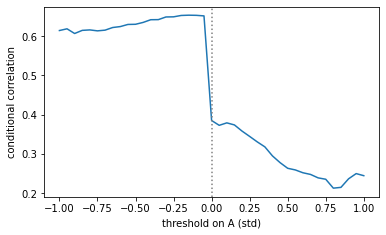

-1.0    0.615
-0.6    0.625
-0.2    0.653
 0.2    0.358
 0.6    0.252
 1.0    0.244
Name: exceedance corr, dtype: float64

In [7]:
curve = exceedance_curve(x, y)
fig, ax = plt.subplots(figsize=(6, 3.5)); ax.plot(curve.index, curve.values); ax.axvline(0, color="grey", ls=":")
ax.set_xlabel("threshold on A (std)"); ax.set_ylabel("conditional correlation"); plt.show()
curve.iloc[::8].round(3)

## Classify the pair

`classify_pair` reduces the curve to the four characteristics of Algorithm 3
(equations C.2 to C.5 of the paper), computed on the thresholds
$z \in [-0.5, 0.5]$. Let $\bar\rho_L$ and $\bar\rho_R$ be the means of the
curve on the left and right sides, $\rho_L^{\max}, \rho_L^{\min}, \rho_R^{\max}, \rho_R^{\min}$
its extremes on each side, $\rho(0^-)$ and $\rho(0^+)$ its two values next to
zero, and the reference level
$\hat\rho_{mid} = \max(\rho(0^-), \rho(0^+)) - \tfrac{1}{2}|\rho(0^-) - \rho(0^+)|$,
the midpoint of the jump. Then

- $\ell = 1$ (stronger on the left) if $\bar\rho_L > \hat\rho_{mid}$ and $\rho_R^{\max} < \hat\rho_{mid}$;
- $u = 1$ (stronger on the right) if $\bar\rho_R > \hat\rho_{mid}$ and $\rho_L^{\max} < \hat\rho_{mid}$;
- $s = \mathrm{sign}(\hat\rho_{AB})$, the sign of the sample (or target) correlation;
- $m = \mathrm{sign}(\min_z \hat\rho(z) \cdot \max_z \hat\rho(z))$: $+1$ monotone, $-1$ when the curve changes sign.

When neither $\ell$ nor $u$ fires, two tiebreakers compare the sides
($\rho_L^{\max} < \rho_R^{\min}$ gives $u = 1$, $\rho_L^{\min} > \rho_R^{\max}$
gives $\ell = 1$, then the side means against the values at zero); if they are
inconclusive, `s` is set to $-11$ as a flag.

In [8]:
c = classify_pair(x, y)
{k: c[k] for k in ["l", "u", "s", "m"]}

{'l': 1, 'u': 0, 's': 1, 'm': 1}

The summary statistics behind the classification: the side means, the side
extremes, the size of the jump at zero $|\rho(0^-) - \rho(0^+)|$, and
$\hat\rho_{mid}$. For a lower-tail pair the left mean exceeds $\hat\rho_{mid}$
and the right maximum stays below it.

In [9]:
c["metrics"].round(3)

mean_leftside        0.647
mean_rightside       0.341
max_leftside         0.655
min_leftside         0.629
max_rightside        0.385
min_rightside        0.269
jump_at0_size        0.266
halfway_from_jump    0.518
dtype: float64

## Select the family

`select_family` runs the selection of Algorithm 3 for one pair. Each family of
the catalog (Gaussian, Student t, Clayton, Gumbel, Frank, Joe and their
rotations) has a known tail signature: its lower- and upper-tail dependence
coefficients

$$\lambda_L = \lim_{u \to 0} \frac{C(u, u)}{u}, \qquad \lambda_U = \lim_{u \to 1} \frac{1 - 2u + C(u, u)}{1 - u},$$

zero or positive (Clayton $\lambda_L = 2^{-1/\theta}$, Gumbel
$\lambda_U = 2 - 2^{1/\theta}$, Gaussian and Frank none, Student t both), the
sign of the dependence it can produce, and whether it is monotone. The
candidates are the families whose signature matches $(\ell, u, s, m)$; each is
fitted by maximum likelihood on the pseudo-observations (ranks divided by
$n + 1$), and the one with the lowest BIC,
$\mathrm{BIC} = -2 \ln L + p \ln n$ with $p$ the number of parameters, is kept
(reported per observation). The truth was a Gumbel 180 with $\theta = 2$.

In [10]:
sel = select_family(x, y)
{k: v for k, v in sel.items() if k != "classification"}

{'status': 'ordinary',
 'family': 'gumbel',
 'rotation': 180,
 'parameters': [2.0206302272383],
 'bic': -0.7600790263275239}

## A non-monotone pair: mixture copulas

A mixture copula is a convex combination $C = w\, C_1 + (1 - w)\, C_2$,
$w \in (0, 1)$, whose density and $h$-functions are the same combinations of
the components'. A mixture of a Clayton rotated by 270 degrees (negative
dependence concentrated in one corner) and a Gumbel (positive dependence in
the opposite corner), with weight $w = 0.7$ on the Clayton, produces a
conditional correlation that changes sign along the threshold, the
equity/bond "flight to quality" pattern of Section 4.4 of the paper.
`simulate_mixture` draws each observation from $C_1$ with probability $w$ and
from $C_2$ otherwise; the marginals are the Johnson SU quantiles as before, and
the curve is $\hat\rho(z)$ on the same grid: negative on the left, positive on
the right, so $m = -1$.

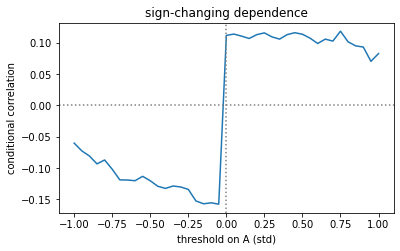

In [11]:
ct = CopulaTools()
comps = [pv.Bicop(pv.BicopFamily.clayton, 270, np.array([[0.7]])), pv.Bicop(pv.BicopFamily.gumbel, 0, np.array([[1.8]]))]
um = ct.simulate_mixture(0.7, comps, n=3000, seed=1)           # weight 0.7 on the Clayton component
xm, ym = jsu_quantile(um[:, 0], pA), jsu_quantile(um[:, 1], pB)
cm = exceedance_curve(xm, ym)
fig, ax = plt.subplots(figsize=(6, 3.5)); ax.plot(cm.index, cm.values); ax.axhline(0, color="grey", ls=":"); ax.axvline(0, color="grey", ls=":")
ax.set_xlabel("threshold on A (std)"); ax.set_ylabel("conditional correlation"); ax.set_title("sign-changing dependence"); plt.show()

With $m = -1$ no single family of the catalog matches the signature, so
`select_family` turns to the mixture catalog: pairs of components with
opposite corners, restricted by $(\ell, u)$, each fitted by maximum likelihood
in $(w, \theta_1, \theta_2)$, the best BIC kept. The estimate is read against
the truth, $w = 0.7$ and $(\theta_1, \theta_2) = (0.7, 1.8)$.

In [12]:
sel = select_family(xm, ym)
{k: v for k, v in sel.items() if k != "classification"}       # truth: weight 0.7, theta (0.7, 1.8)

{'status': 'mixture',
 'family': ['clayton', 'gumbel'],
 'rotation': [270, 0],
 'parameters': [0.6951463740818703, 0.6429239498890819, 1.7775385051225867],
 'bic': -0.08539662564637157}